# Testing on the internal dataset

In [1]:
%matplotlib inline

### Start

In [2]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:64'


In [3]:

from comet_ml import Experiment
# from fastai.callback.comet import CometCallback

from fastai.vision.all import *
from fastai.basics import *
from fastai.callback.all import *
from fastai.medical.imaging import *
from fastai.data.transforms import IndexSplitter
from fastai.data.core import DataLoaders
from fastai.vision.data import PILImage   
from fastai.learner import Learner
from fastai.losses import BCEWithLogitsLossFlat
import torch
import torch.nn.functional as F

#..... Transforms........
from fastai.vision.augment import RandTransform
from fastai.vision.core import TensorImage
from torchvision.transforms.functional import rotate as tv_rotate
from torchvision.transforms.functional import affine as tv_affine
#from fastai.vision.augment import brightness
from torchvision.transforms.functional import adjust_brightness
from torchvision.transforms.functional import adjust_contrast
import random

import math
import timm

from PIL import Image 
import pydicom

from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import roc_curve, auc
import requests
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import cv2
from captum.attr import Occlusion
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask



/home2/rosmeri/myenv/lib/python3.11/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [4]:
### Securing space on the GPU (though not necessary)

import torch

# Comprobar si hay una GPU disponible, cuál es y seleccionar "device 0"
if torch.cuda.is_available():
    device = torch.device('cuda:0')
    print(f"GPU disponible: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')
    print("GPU no disponible, usando CPU.") 


GPU disponible: NVIDIA GeForce RTX 3060


In [5]:
from fastai.vision.all import *
defaults.device = device
device


device(type='cuda', index=0)

### Reading data

In [6]:
# Path where the folders containing the grouped Trian image folders are located
# Path donde se localizan las capretas que tienen agrupadas las carpetas de imágenes de trian
source = Path('/home.../lung_cancer_dataset')
data_dir = source

# Path to the folders containing the NLST images (normalized and converted to JPG so the pre-trained model can recognize them) for this testing.
# Path donde están las capretas de las imágenes de NLST (normalizadas e igualmente convertidas a jpg para que el modelo ya entrenado pueda reconocerlas) este testeo.
test_files = Path('/home.../Test_set')
test_dir=test_files

'''
the suffix _B: images within the folder with this name (B)
the suffix _N: images within the folder with this name (N)
the suffix _M: images within the folder with this name (M)
'''

'\nthe suffix _B: images within the folder with this name (B)\nthe suffix _N: images within the folder with this name (N)\nthe suffix _M: images within the folder with this name (M)\n'

### Defining the transformations to apply data augmentation

In [7]:

#....................    GAUSSIAN NOISE   ..........................#

class AddGaussianNoise(RandTransform):
    "Agregando ruido gaussiano a la imagen con cierta probabilidad"
    '''
    OjO haciéndolo si establecer un rango, la primera vez lo hice con un solo valor y ahora también 
    
    '''
    def __init__(self, std: float=10.0, p: float=0.5):  #primeros valores sencillos
        super().__init__(p=p)
        self.std = std
        self.applied = False

    def before_call(self, b, split_idx):
        self.applied = random.random() < self.p

    def encodes(self, img: TensorImage):
        if not self.applied:
            return img
        # Convertir a float para evitar errores con Byte
        img = img.float()
        noise = torch.randn_like(img) * self.std
        noisy_img = img + noise
        return noisy_img.clamp(0, 255)  # Clampea para evitar overflow si es 8-bit


#....................   TRANSLATION   ........................#

class AddTranslation(RandTransform):
    "Aplicando traslación aleatoria dentro del rango [-max_shift, max_shift]"
    '''
     Tamaño imagen: alto=512px, ancho=512px
     Máximo desplazamiento: ±77px
     Desplazamiento máximo en %: ±15.0% vertical, ±15.0% horizontal
    '''
    def __init__(self, max_shift: int = 77, p: float = 0.75):   # 77
        super().__init__(p=p)
        self.max_shift = max_shift
        self.shift_x = 0
        self.shift_y = 0
        self.applied = False  # Inicialmente no aplicada

    def before_call(self, b, split_idx):
        self.applied = random.random() < self.p
        if self.applied:
            self.shift_x = random.randint(-self.max_shift, self.max_shift)
            self.shift_y = random.randint(-self.max_shift, self.max_shift)
  
        else:
            self.shift_x = 0
            self.shift_y = 0

    def encodes(self, img: TensorImage):
        if not self.applied:
            return img
        img = img.float()

        return tv_affine(img, angle=0.0, translate=[self.shift_x, self.shift_y], scale=1.0, shear=[0.0, 0.0])



In [8]:
#....................    ROTATE   ............................#

class MyRandomRotate(RandTransform):
    
    def __init__(self, max_deg=10, p=0.75):  # p=1.0 asegura que siempre se aplique para probar
        super().__init__(p=p)
        self.max_deg = max_deg
        self.last_angle = None  # para guardar el valor

    def before_call(self, b, split_idx):
        "Elegir el ángulo aleatorio antes de aplicar"
        self.last_angle = random.uniform(-self.max_deg, self.max_deg)

    def encodes(self, x: TensorImage):
        "Aplicar rotación"
        return tv_rotate(x, self.last_angle)
        

#....................    ZOOM   ..........................#

class MyRandomZoom(RandTransform):
   
    def __init__(self, min_zoom=0.9, max_zoom=1.10, p=0.75):
        super().__init__(p=p)
        self.min_zoom = min_zoom
        self.max_zoom = max_zoom
        self.last_zoom = None

    def before_call(self, b, split_idx):
        self.last_zoom = random.uniform(self.min_zoom, self.max_zoom)
        super().before_call(b, split_idx)

    def encodes(self, x: TensorImage):
        if x.ndim == 3:
            # Una sola imagen: (C, H, W)
            _, h, w = x.shape
        elif x.ndim == 4:
            # Lote de imágenes: (B, C, H, W)
            _, _, h, w = x.shape
        else:
            raise ValueError(f"Shape inesperado: {x.shape}")

    # Inverse of zoom is scale in affine: 1.0 / zoom
        scale = self.last_zoom
        return tv_affine(x, angle=0.0, translate=[0, 0], scale=scale, shear=[0.0, 0.0])



#....................   FLIP HORIZONTAL   ...............................#

class MyRandomFlip(RandTransform):
    
    def __init__(self, p=0.75):
        super().__init__(p=p)
        self.flipped_h = None

    def before_call(self, b, split_idx):
        self.flipped_h = random.random() < self.p

    def encodes(self, x: TensorImage):
        if self.flipped_h:
            return torch.flip(x, dims=[2])  # Flip horizontal (dim 2)
        return x

#....................    FLIP VERTICAL   .............................#

class MyRandomFlipVert(RandTransform):
    
    def __init__(self, p=0.75):
        super().__init__(p=p)
        self.flipped_v = None

    def before_call(self, b, split_idx):
        self.flipped_v = random.random() < self.p

    def encodes(self, x: TensorImage):
        if self.flipped_v:
            return torch.flip(x, dims=[1])  # Flip vertical (dim 1)
        return x
        

#....................  ILUMINACIÓN (BRIGHTNESS Y CONTRASTE)    ........................#

class MyRandomLighting(RandTransform):
    
    def __init__(self, max_lighting=0.2, p=0.75):
        super().__init__(p=p)
        self.max_lighting = max_lighting
        self.last_brightness = 1.0
        self.applied = False

    def before_call(self, b, split_idx):
        self.applied = random.random() < self.p
        
        if self.applied:
            '''
            debe hacer así 
            -0.5 * (1 - max_lighting)   y   +0.5 * (1 + max_lighting)
            y luego  convertirlo a un factor válido sumando 1
            '''
            min_val = -0.5 * (1 - self.max_lighting)
            max_val = +0.5 * (1 + self.max_lighting)
            brightness_change = random.uniform(min_val, max_val)
            self.last_brightness = 1 + brightness_change
        else:
            self.last_brightness = 1.0
    
    def encodes(self, x: TensorImage):
        if self.applied:
            return adjust_brightness(x, brightness_factor=self.last_brightness)
        return x



class MyRandomContrast(RandTransform):
    def __init__(self, max_contrast=0.2, p=0.75):
        super().__init__(p=p)
        self.max_contrast = max_contrast
        self.last_contrast = 1.0
        self.applied = False

    def before_call(self, b, split_idx):
        self.applied = random.random() < self.p
        
        if self.applied:
            low = 1 - self.max_contrast
            high = 1 / (1 - self.max_contrast)
            log_low = math.log(low)
            log_high = math.log(high)
            self.last_contrast = math.exp(random.uniform(log_low, log_high))
        else:
            self.last_contrast = 1.0
    
    def encodes(self, x: TensorImage):
        if self.applied:
            return adjust_contrast(x, contrast_factor=self.last_contrast)
        return x




### Applying transforms and loading data

In [9]:

my_transforms = [
    #ToFloatAndScale(),         # Escala a [0,1]   
    #3MyRandomRotate(max_deg=5, p=0.5),
    #MyRandomZoom(min_zoom=0.90, max_zoom=1.05, p=0.5),
    #MyRandomFlip(p=0.5), # poco recomendado
    #MyRandomFlipVert(p=0.5),
    #MyRandomLighting(max_lighting=0.1, p=0.5),
    #MyRandomContrast(max_contrast=0.1, p=0.5),
    #AddGaussianNoise(std=5.0, p=0.5), #registry=transform_log_registry
    #AddTranslation(max_shift=20, p=0.5),  #77
    #Clamp(),                   # Asegura que no se pase
    Normalize.from_stats(*imagenet_stats),  # *imagenet_stats ### 
]

In [10]:

dls = ImageDataLoaders.from_folder(
    data_dir,
    valid_pct=0.2,  
    item_tfms=Resize(512, method='pad',pad_mode='zeros' ),  
    batch_tfms=my_transforms,  
    seed=42,  
    bs=8, 
    drop_last=False,   
    num_workers=0,
)

### Model loading and learner creation

In [11]:

learn = vision_learner(
    dls,
    'efficientnet_b1', 
    pretrained= True,
    loss_func=CrossEntropyLossFlat(),
    metrics=[accuracy, Precision(average='macro'), Recall(average='macro'), F1Score(average='macro')],
    model_dir='_Ef_',
).to_fp16()

learn.load('E-1500') 

/home2/rosmeri/myenv/lib/python3.11/site-packages/fastai/learner.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(file, map_location=device, **torch_l

In [12]:
print(learn.dls.vocab)

['Bengin', 'Malignant', 'Normal']


### Testing y Predictions

In [13]:
valid_exts = ['.jpg', '.jpeg', '.png']

# Create a list of paths to all images in the test directory
# This searches inside the directory folder and also searches within the three subfolders inside it.
test_files = list(test_dir.glob('**/*'))   

# in case there are hidden folders
test_files = [f for f in test_dir.rglob('*') 
              if f.is_file() and f.suffix.lower() in valid_exts and '.ipynb_checkpoints' not in f.parts]


In [14]:

# Get the DataLoader for the test set
test_dl = learn.dls.test_dl(test_files, with_labels=True)

# Evaluate metrics on the test set
results = learn.validate(dl=test_dl)

# Get predictions and true labels
preds, targs = learn.get_preds(dl=test_dl)

# Probabilities by class
preds = torch.argmax(preds, dim=1)

/home2/rosmeri/myenv/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/home2/rosmeri/myenv/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


/home2/rosmeri/myenv/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/home2/rosmeri/myenv/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


In [15]:
print(f"True labels: {targs}")
print(f"Predicted labels: {preds}")

True labels: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2])
Predicted labels: tensor([0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [16]:

# Print the results with clear metric names
metrics_name = ['accuracy', 'precision', 'recall', 'f1_score']
metrics_values = results[1:]  # Exclude the first value (it appears to be loss)
results_dict = dict(zip(metrics_name, metrics_values)) # creating a dictionary of the metrics 


print("Full results:")
for metric_name, metric_value in results_dict.items():
    print(f"{metric_name.capitalize()}: {metric_value:.4f}")

Full results:
Accuracy: 0.9955
Precision: 0.9961
Recall: 0.9861
F1_score: 0.9909


In [17]:
report = classification_report(targs, preds, target_names=dls.vocab)
print(report)

              precision    recall  f1-score   support

      Bengin       1.00      0.96      0.98        24
   Malignant       1.00      1.00      1.00       113
      Normal       0.99      1.00      0.99        84

    accuracy                           1.00       221
   macro avg       1.00      0.99      0.99       221
weighted avg       1.00      1.00      1.00       221



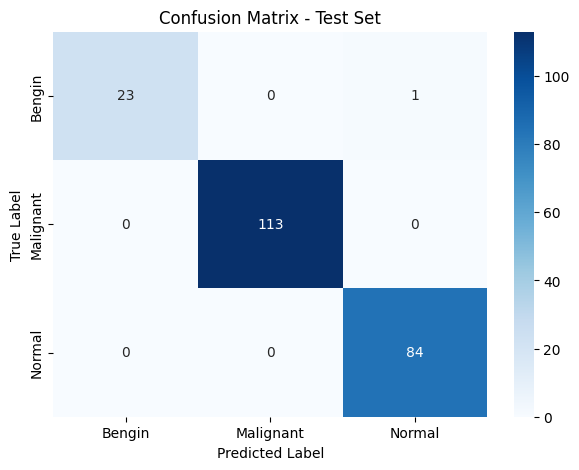

In [18]:
# confusion_matrix

cm = confusion_matrix(targs, preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=learn.dls.vocab, yticklabels=learn.dls.vocab)


plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

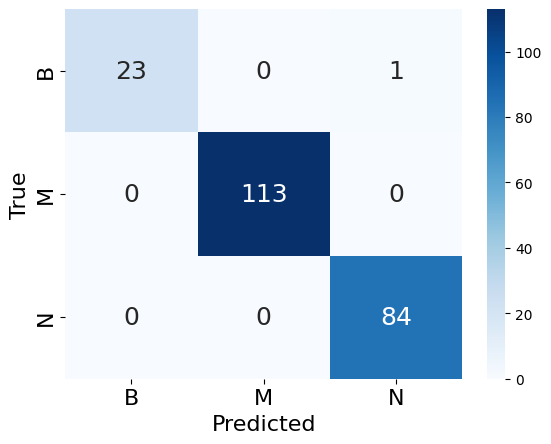

In [19]:

abbreviations = ['B', 'M', 'N']  
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            xticklabels=['B', 'M', 'N'], 
            yticklabels=['B', 'M', 'N'],
            annot_kws={"size": 18})  
plt.xticks(fontsize=16)  # size on the x-axis
plt.yticks(fontsize=16)  # size on the y-axis


plt.xlabel('Predicted', fontsize=16)
plt.ylabel('True', fontsize=16)
plt.show()


/home2/rosmeri/myenv/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/home2/rosmeri/myenv/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


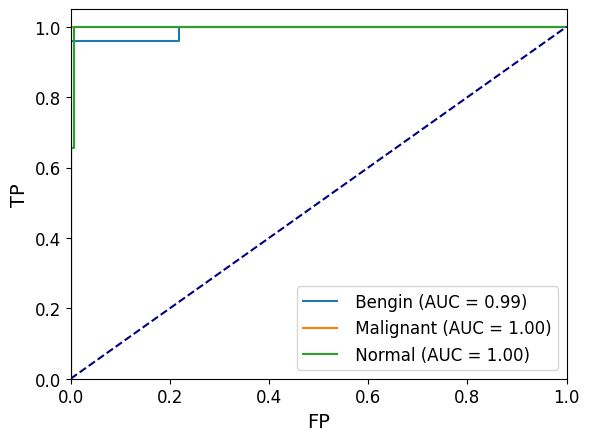

In [20]:

# Predictions and true labels
preds, targs = learn.get_preds(dl=test_dl)

targs_numpy = targs.cpu().numpy()  # convert to NumPy
preds_softmax = torch.softmax(preds, dim=1)  # Convert predictions to probabilities
preds_numpy = preds_softmax.cpu().numpy()  

# dictionaries to store the curves and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

# Calculating the ROC curve and AUC for each class
for i in range(len(learn.dls.vocab)):
    fpr[i], tpr[i], _ = roc_curve(targs_numpy == i, preds_numpy[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

    plt.plot(fpr[i], tpr[i], label=f' {learn.dls.vocab[i]} (AUC = {roc_auc[i]:.2f})')

# Draw the diagonal line of randomness (AUC = 0.5)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')

# axis limits
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('FP', fontsize=14)
plt.ylabel('TP', fontsize=14)

plt.legend(loc='lower right', fontsize=12)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)


#plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')

plt.show()


### XAI

Clase predicha: Bengin


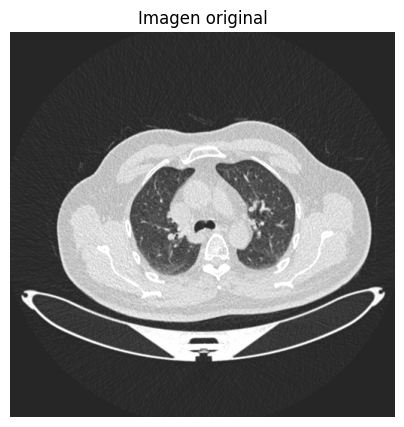

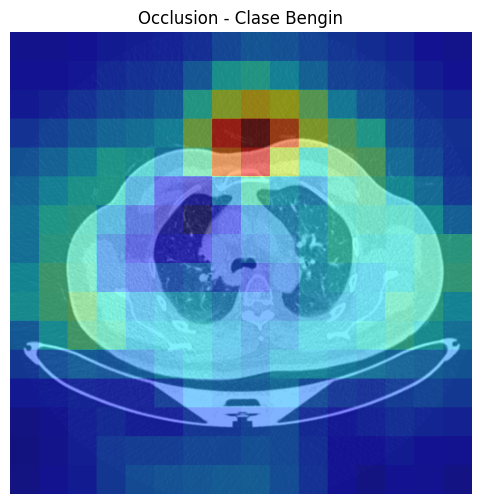

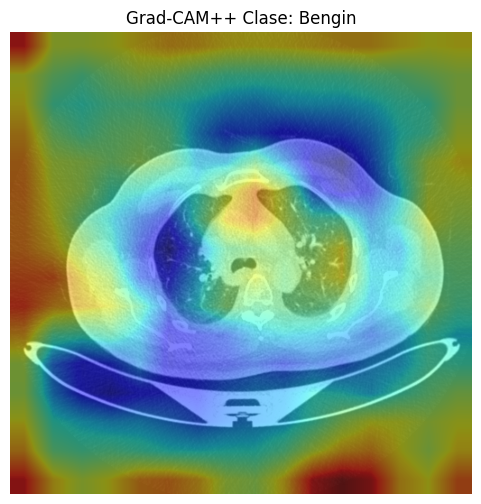

In [21]:

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Prepare image
img_path = test_files[0]   
                             # 10 Benigno 
                             # 158 Normal 
                             
img = PILImage.create(img_path)
img_tensor = learn.dls.test_dl([img]).one_batch()[0].to(device)
model = learn.model.eval().to(device)

# Prediction
with torch.no_grad():
    output = model(img_tensor)
pred_class = output.argmax(dim=1).item()
print(f"Clase predicha: {dls.vocab[pred_class]}")
img.show(title="Imagen original")

# Convert PIL to NumPy array and save
img_np_save = np.array(img)
#plt.imsave("imagen_original_10.png", img_np_save)


#.............. Occlusion ................#
occlusion = Occlusion(model)
attributions = occlusion.attribute(
    img_tensor,
    strides=(1, 32, 32),
    sliding_window_shapes=(1, 64, 64),
    baselines=0,  # baseline negro
    target=pred_class
)

attr = attributions.squeeze().cpu().detach().numpy()
if attr.ndim == 3: 
    attr = attr.mean(axis=0)
attr_norm = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)

# Guardar
plt.figure(figsize=(6,6))
plt.imshow(img)  
plt.imshow(attr_norm, cmap='jet', alpha=0.5)
plt.axis('off')
plt.title(f'Occlusion - Clase {dls.vocab[pred_class]}')
#plt.savefig("imagen_occlusion_10.png", bbox_inches='tight', dpi=300)
plt.show()  


#..............  Grad-CAM++ ................#
# Elegimos la última capa conv (TimmBody ejemplo)
last_conv = learn.model[0].model.conv_head

activations = {}
gradients = {}

def forward_hook(module, input, output):
    activations['value'] = output.detach()
def backward_hook(module, grad_input, grad_output):
    gradients['value'] = grad_output[0].detach()

handle_fw = last_conv.register_forward_hook(forward_hook)
handle_bw = last_conv.register_full_backward_hook(backward_hook)

# Forward with gradients
img_tensor_req = img_tensor.clone().detach().requires_grad_(True)
out = model(img_tensor_req)
score = out[0, pred_class]
score.backward()

grads = gradients['value'][0]
acts = activations['value'][0]

#.................. Grad-CAM++ weights ................#
grads2 = grads**2
grads3 = grads**3
sum_acts = acts.view(acts.size(0), -1).sum(-1).view(-1,1,1).abs()
eps = 1e-8
alphas = grads2 / (2*grads2 + sum_acts*grads3 + eps)
alphas = torch.where(torch.isnan(alphas), torch.zeros_like(alphas), alphas)
weights = (alphas * grads).sum(dim=(1,2))

gradcam = (weights[:,None,None]*acts).sum(0).relu()
gradcam -= gradcam.min()
gradcam /= gradcam.max()

# Resize to original size
gradcam_resized = F.interpolate(
    gradcam.unsqueeze(0).unsqueeze(0),
    size=img.size[::-1],
    mode='bilinear',
    align_corners=False
)[0,0]

# Overlay y mostrar

#.................... Threshold for highlighting important regions ................#

img_np = np.array(img).astype(np.float32)/255.0
gradcam_np = gradcam_resized.cpu().numpy()

#plt.savefig("imagen_gradcam_14.png", bbox_inches='tight', dpi=300)
plt.figure(figsize=(6,6))
plt.imshow(img_np)
plt.imshow(gradcam_np, cmap='jet', alpha=0.5)
plt.axis('off')
plt.title(f"Grad-CAM++ Clase: {dls.vocab[pred_class]}")
#plt.savefig("imagen_gradcam_10.png", bbox_inches='tight', dpi=300)
plt.show()

# Clean up hooks
handle_fw.remove()
handle_bw.remove()


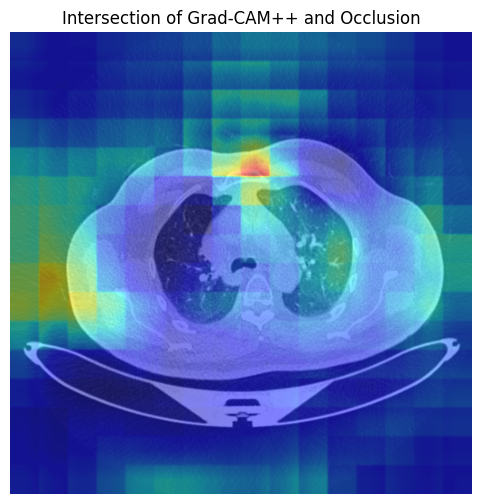

In [22]:

#............... Smooth maps () ..............#
sigma = 1
attr_smooth = cv2.GaussianBlur(attr_norm, (0,0), sigma)
gradcam_smooth = cv2.GaussianBlur(gradcam_np, (0,0), sigma)

#............... Normalizar ambos mapas a [0,1]  ..............#
attr_normed = (attr_smooth - attr_smooth.min()) / (attr_smooth.max() - attr_smooth.min() + 1e-8)
grad_normed = (gradcam_smooth - gradcam_smooth.min()) / (gradcam_smooth.max() - gradcam_smooth.min() + 1e-8)

#............... Calculate smooth intersection ..............#
intersection_map = attr_normed * grad_normed  

#................ Show over original image ..............#
img_np = np.array(img).astype(np.float32)/255.0  # si img es PIL


plt.figure(figsize=(6,6))
plt.imshow(img_np)
plt.imshow(intersection_map, cmap='jet', alpha=0.5)
plt.axis('off')
plt.title("Intersection of Grad-CAM++ and Occlusion")
#plt.savefig("interseccion_gradcam_occlusion_10.png", bbox_inches='tight', dpi=300)
plt.show() 


In [23]:

from scipy.ndimage import center_of_mass
from scipy.stats import pearsonr

# attr_normed, grad_normed, intersection_map already defined and in [0,1]
eps = 1e-10

# Sums / masses
sum_attr = attr_normed.sum()
sum_grad = grad_normed.sum()
sum_inter = intersection_map.sum()

# 1. Overlap mass (sum of intersection)
overlap_mass = sum_inter

# 2. Dice continuo (soft-Dice)
dice_soft = 2 * sum_inter / (np.sum(attr_normed**2) + np.sum(grad_normed**2) + eps)

# 3. Jaccard continuo (soft-IoU)
jaccard_soft = sum_inter / (sum_attr + sum_grad - sum_inter + eps)

# 4. Coverage (what fraction of each map covers the other)
cover_attr = sum_inter / (sum_attr + eps)   
cover_grad = sum_inter / (sum_grad + eps)   

# 5. Intersection peak and peak positions
max_intersection = intersection_map.max()
peak_inter_pos = np.unravel_index(np.argmax(intersection_map), intersection_map.shape)
peak_attr_pos = np.unravel_index(np.argmax(attr_normed), attr_normed.shape)
peak_grad_pos = np.unravel_index(np.argmax(grad_normed), grad_normed.shape)

# 6. Area above threshold (e.g., top 5% of intersection)
p = 95
th = np.percentile(intersection_map, p)
area_above = np.sum(intersection_map >= th)
area_prop = area_above / (intersection_map.size + eps)

# 7. Centers of mass and distances
c_inter = center_of_mass(intersection_map) if sum_inter > 0 else (np.nan, np.nan)
c_attr = center_of_mass(attr_normed) if sum_attr > 0 else (np.nan, np.nan)
c_grad = center_of_mass(grad_normed) if sum_grad > 0 else (np.nan, np.nan)

def dist(a,b):
    return np.linalg.norm(np.array(a) - np.array(b)) if not (np.isnan(a[0]) or np.isnan(b[0])) else np.nan

dist_inter_attr = dist(c_inter, c_attr)
dist_inter_grad = dist(c_inter, c_grad)
dist_attr_grad = dist(c_attr, c_grad)

# 8. Strong global and within-zone Pearson correlation
corr_global, _ = pearsonr(attr_normed.flatten(), grad_normed.flatten())

# correlation restricted to strong intersection (e.g., >= 90th percentile)
mask_corr = intersection_map >= np.percentile(intersection_map, 90)
if np.any(mask_corr):
    a_masked = attr_normed[mask_corr]
    g_masked = grad_normed[mask_corr]
    corr_local = pearsonr(a_masked.flatten(), g_masked.flatten())[0]
else:
    corr_local = np.nan


metrics = {
  #  "overlap_mass": float(overlap_mass),
    "dice_soft": float(dice_soft),
    "jaccard_soft": float(jaccard_soft),
    "cover_attr": float(cover_attr),
    "cover_grad": float(cover_grad)  #,
  #  "max_intersection": float(max_intersection),
  #  "peak_inter_pos": tuple(map(int, peak_inter_pos)),
  #  "peak_attr_pos": tuple(map(int, peak_attr_pos)),
  #  "peak_grad_pos": tuple(map(int, peak_grad_pos)),
  #  "area_top5pct": int(area_above),
  #  "area_top5pct_prop": float(area_prop),
  #  "center_inter": tuple(c_inter),
  #  "center_attr": tuple(c_attr),
  #  "center_grad": tuple(c_grad),
  #  "dist_inter_attr": float(dist_inter_attr) if not np.isnan(dist_inter_attr) else np.nan,
  #  "dist_inter_grad": float(dist_inter_grad) if not np.isnan(dist_inter_grad) else np.nan,
  #  "dist_attr_grad": float(dist_attr_grad) if not np.isnan(dist_attr_grad) else np.nan,
  #  "corr_global": float(corr_global),
  #  "corr_local_top10pct": float(corr_local) if not np.isnan(corr_local) else np.nan
}

for k,v in metrics.items():
    print(f"{k}: {v}")


dice_soft: 0.694528029778469
jaccard_soft: 0.19127323730001308
cover_attr: 0.42502874945588653
cover_grad: 0.25804180527497417


### Más pruebas

In [24]:
import re

def extract_case_number(path):
    match = re.search(r'(\d+)', path.stem)
    return int(match.group(1)) if match else None


In [25]:

MERGED_ROOT=Path('/home.../Test_set')
valid_exts = ['.jpg', '.jpeg', '.png']

def scan_full_dataset(root):
    return [f for f in root.rglob('*') if f.is_file() and f.suffix.lower() in valid_exts and '.ipynb_checkpoints' not in f.parts]

all_paths = scan_full_dataset(MERGED_ROOT)

CLASS_FOLDER = 'Normal'  #  Malignant ó Bengin
items_N = sorted([(extract_case_number(p), p) for p in all_paths if p.parent.name == CLASS_FOLDER], key=lambda x: x[0])
print(f"Total imágenes clase {CLASS_FOLDER}: {len(items_N)}")


Total imágenes clase Normal: 84


In [26]:
'''
from scipy.ndimage import center_of_mass
from scipy.stats import pearsonr
'''
TEST_ROOT = Path('/home.../Test_set')
valid_exts = ['.jpg', '.jpeg', '.png']

def scan_test_folder(root, class_name):
    return sorted([f for f in (root / class_name).rglob('*')
                   if f.is_file() and f.suffix.lower() in valid_exts])

class_folders = {'Bengin': 'B', 'Malignant': 'M', 'Normal': 'N'}
all_results = []

#### To create the figure "Consistency between Grad-CAM++ and Occlusion over the entire test set by diagnostic class"

In [ ]:
for folder_name, short_name in class_folders.items():
    paths = scan_test_folder(TEST_ROOT, folder_name)
    print(f"Processing {folder_name}: {len(paths)} images")

    for img_path in paths:
        '''
        FROM THIS POINT ON: exactly
        - Occlusion block, Grad-CAM++
        - smoothing block + intersection unchanged
        - and metric calculation, as is
        - replacing only 'img_path = test_files[0]'
        '''

        ''' bloque de Occlusion, Grad-CAM++'''
        
        img = PILImage.create(img_path)
        img_tensor = learn.dls.test_dl([img]).one_batch()[0].to(device)
        model = learn.model.eval().to(device)

        with torch.no_grad():
            output = model(img_tensor)
        pred_class = output.argmax(dim=1).item()
        print(f"Predicted class: {dls.vocab[pred_class]}")

        occlusion = Occlusion(model)
        attributions = occlusion.attribute(
            img_tensor,
            strides=(1, 32, 32),
            sliding_window_shapes=(1, 64, 64),
            baselines=0, 
            target=pred_class
        )
        attr = attributions.squeeze().cpu().detach().numpy()
        if attr.ndim == 3: 
            attr = attr.mean(axis=0)
        attr_norm = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)

        occlusion_valido = not np.isnan(attr_norm).any() and (attr.max() - attr.min()) > 1e-6
        
        # We select the last conv layer (TimmBody example)
        last_conv = learn.model[0].model.conv_head

        activations = {}
        gradients = {}

        def forward_hook(module, input, output):
            activations['value'] = output.detach()

        def backward_hook(module, grad_input, grad_output):
            gradients['value'] = grad_output[0].detach()

        handle_fw = last_conv.register_forward_hook(forward_hook)
        handle_bw = last_conv.register_full_backward_hook(backward_hook)

        # Forward pass with gradients
        img_tensor_req = img_tensor.clone().detach().requires_grad_(True)
        out = model(img_tensor_req)
        score = out[0, pred_class]
        score.backward()

        grads = gradients['value'][0]
        acts = activations['value'][0]

        # Grad-CAM++ weights
        grads2 = grads**2
        grads3 = grads**3
        sum_acts = acts.view(acts.size(0), -1).sum(-1).view(-1, 1, 1).abs()
        eps = 1e-8

        alphas = grads2 / (2 * grads2 + sum_acts * grads3 + eps)
        alphas = torch.where(
            torch.isnan(alphas),
            torch.zeros_like(alphas),
            alphas
        )

        weights = (alphas * grads).sum(dim=(1, 2))

        gradcam = (weights[:, None, None] * acts).sum(0).relu()
        gradcam -= gradcam.min()
        gradcam /= gradcam.max()

        # Resize to original size
        gradcam_resized = F.interpolate(
            gradcam.unsqueeze(0).unsqueeze(0),
            size=img.size[::-1],
            mode='bilinear',
            align_corners=False
        )[0, 0]

        # Threshold for highlighting important regions

        img_np = np.array(img).astype(np.float32)/255.0
        gradcam_np = gradcam_resized.cpu().numpy()

        # Cleaning hooks
        handle_fw.remove()
        handle_bw.remove()

        ''' same smoothing block + intersection unchanged '''

        sigma = 1

        if attr_norm.shape != gradcam_np.shape:
            attr_norm = cv2.resize(attr_norm, (gradcam_np.shape[1], gradcam_np.shape[0]))
    
        attr_smooth = cv2.GaussianBlur(attr_norm, (0,0), sigma)
        gradcam_smooth = cv2.GaussianBlur(gradcam_np, (0,0), sigma)
        
        attr_normed = (attr_smooth - attr_smooth.min()) / (attr_smooth.max() - attr_smooth.min() + 1e-8)
        grad_normed = (gradcam_smooth - gradcam_smooth.min()) / (gradcam_smooth.max() - gradcam_smooth.min() + 1e-8)
        
        intersection_map = attr_normed * grad_normed  
        
        ''' metric calculation'''
        eps = 1e-10

        sum_attr = attr_normed.sum()
        sum_grad = grad_normed.sum()
        sum_inter = intersection_map.sum()

        overlap_mass = sum_inter

        dice_soft = 2 * sum_inter / (np.sum(attr_normed**2) + np.sum(grad_normed**2) + eps)

        jaccard_soft = sum_inter / (sum_attr + sum_grad - sum_inter + eps)

        cover_attr = sum_inter / (sum_attr + eps)   
        cover_grad = sum_inter / (sum_grad + eps)   
    
        metrics = {
          #  "overlap_mass": float(overlap_mass),
            "dice_soft": float(dice_soft),
            "jaccard_soft": float(jaccard_soft),
            "cover_attr": float(cover_attr),
            "cover_grad": float(cover_grad)  #,

        }

        for k,v in metrics.items():
            print(f"{k}: {v}")


        metrics['clase'] = short_name
        metrics['imagen'] = img_path.name
        metrics['occlusion_valido'] = occlusion_valido
        
        all_results.append(dict(metrics))

df_xai = pd.DataFrame(all_results)
  

In [ ]:
summary = df_xai.groupby('clase')[['dice_soft', 'jaccard_soft', 'cover_attr', 'cover_grad']].agg(['mean', 'std'])
print(summary)

#### To create a table of: Model size, computational cost and inference time by architecture.

In [28]:
# pip install thop --break-system-packages

#### Efficienet

Time on comet --> 07:09:23

In [29]:
learn_ef = vision_learner(
    dls,
    'efficientnet_b1', 
    pretrained= True,
    loss_func=CrossEntropyLossFlat(),
    metrics=[accuracy, Precision(average='macro'), Recall(average='macro'), F1Score(average='macro')],
    model_dir='_Ef_',
).to_fp16()

learn_ef.load('E-1500') 

/home2/rosmeri/myenv/lib/python3.11/site-packages/fastai/learner.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(file, map_location=device, **torch_l

In [30]:
n_params_ef = sum(p.numel() for p in learn_ef.model.parameters())
print(f"Parameters: {n_params_ef:,}")

Parameters: 7,831,584


In [31]:
from thop import profile
import torch

learn_ef.model = learn_ef.model.to(device)

dummy_input_ef = torch.randn(1, 3, 512, 512).to(device)
flops_ef, _ = profile(learn_ef.model, inputs=(dummy_input_ef,))
print(f"FLOPs: {flops_ef:,}")

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register count_adap_avgpool() for <class 'torch.nn.modules.pooling.AdaptiveAvgPool2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.AdaptiveMaxPool2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm1d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.dropout.Dropout'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
FLOPs: 2,966,422,784.0


In [32]:
test_root=test_dir
img_path_ejemplo = next(test_root.rglob('*.jpg'))  
img = PILImage.create(img_path_ejemplo)

from thop.utils import clever_format
for module in learn_ef.model.modules():
    if hasattr(module, 'total_ops'):
        del module.total_ops
    if hasattr(module, 'total_params'):
        del module.total_params

import time

#img = PILImage.create(test_files[0])
img_tensor = learn_ef.dls.test_dl([img]).one_batch()[0].to(device)

learn_ef_2 = vision_learner(
    dls, 'efficientnet_b1', pretrained=True,
    loss_func=CrossEntropyLossFlat(),
    model_dir='_Ef_',
).to_fp16()
learn_ef_2.load('E-1500')
learn_ef_2.model = learn_ef_2.model.to(device).eval()

with torch.no_grad():
    torch.cuda.synchronize()
    start = time.time()
    _ = learn_ef_2.model(img_tensor)
    torch.cuda.synchronize()
print(f"Inference time: {(time.time()-start)*1000:.2f} ms")


Inference time: 13.25 ms


#### Densenet

Time on comet --> 16:59:46

In [33]:
learn_den = vision_learner(
    dls,
    'densenet169', 
    pretrained= True,
    loss_func=CrossEntropyLossFlat(),
    metrics=[accuracy, Precision(average='macro'), Recall(average='macro'), F1Score(average='macro')],
    model_dir='_DNet_',
).to_fp16()

learn_den.load('D-2000') 

In [34]:
n_params_den = sum(p.numel() for p in learn_den.model.parameters())
print(f"Parameters: {n_params_den:,}")

Parameters: 14,197,632


In [35]:
learn_den.model = learn_den.model.to(device)

dummy_input_den = torch.randn(1, 3, 512, 512).to(device)  
flops_den, _ = profile(learn_den.model, inputs=(dummy_input_den,))
print(f"FLOPs: {flops_den:,}")

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.MaxPool2d'>.
[INFO] Register count_avgpool() for <class 'torch.nn.modules.pooling.AvgPool2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register count_adap_avgpool() for <class 'torch.nn.modules.pooling.AdaptiveAvgPool2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.dropout.Dropout'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.AdaptiveMaxPool2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm1d'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
FLOPs: 17,547,872,384.0


In [36]:

test_root=test_dir
img_path_ejemplo = next(test_root.rglob('*.jpg')) 
img = PILImage.create(img_path_ejemplo)


from thop.utils import clever_format
for module in learn_den.model.modules():
    if hasattr(module, 'total_ops'):
        del module.total_ops
    if hasattr(module, 'total_params'):
        del module.total_params

import time
#img = PILImage.create(test_files[0])
img_tensor_den = learn_den.dls.test_dl([img]).one_batch()[0].to(device)

learn_den_2 = vision_learner(
    dls, 'densenet169', pretrained=True,
    loss_func=CrossEntropyLossFlat(),
    model_dir='_DNet_',
).to_fp16()
learn_den_2.load('D-2000')
learn_den_2.model = learn_den_2.model.to(device).eval()

with torch.no_grad():
    torch.cuda.synchronize()
    start = time.time()
    _ = learn_den_2.model(img_tensor_den)
    torch.cuda.synchronize()
print(f"Inference time: {(time.time()-start)*1000:.2f} ms")



Inference time: 24.68 ms


#### ResNet-50

Time on comet --> 10:25:22

In [37]:
learn_res50 = vision_learner(
    dls,
    resnet50, 
    pretrained= True,
    loss_func=CrossEntropyLossFlat(),
    metrics=[accuracy, Precision(average='macro'), Recall(average='macro'), F1Score(average='macro')],
    model_dir='resnet50',
).to_fp16()

learn_res50.load('R50-2000') 

In [38]:
n_params_res50 = sum(p.numel() for p in learn_res50.model.parameters())
print(f"Parameters: {n_params_res50:,}")

Parameters: 25,615,936


In [39]:
learn_res50.model = learn_res50.model.to(device)

dummy_input_res50 = torch.randn(1, 3, 512, 512).to(device) 
flops_res50, _ = profile(learn_res50.model, inputs=(dummy_input_res50,))
print(f"FLOPs: {flops_res50:,}")

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.MaxPool2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register count_adap_avgpool() for <class 'torch.nn.modules.pooling.AdaptiveAvgPool2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.AdaptiveMaxPool2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm1d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.dropout.Dropout'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
FLOPs: 21,588,104,704.0


In [40]:

test_root=test_dir
img_path_ejemplo = next(test_root.rglob('*.jpg'))  #
img = PILImage.create(img_path_ejemplo)


from thop.utils import clever_format
for module in learn_res50.model.modules():
    if hasattr(module, 'total_ops'):
        del module.total_ops
    if hasattr(module, 'total_params'):
        del module.total_params

import time

#img = PILImage.create(test_files[0])
img_tensor_res50 = learn_res50.dls.test_dl([img]).one_batch()[0].to(device)

learn_res50_2 = vision_learner(
    dls, resnet50, pretrained=True,
    loss_func=CrossEntropyLossFlat(),
    model_dir='resnet50',
).to_fp16()
learn_res50_2.load('R50-2000')
learn_res50_2.model = learn_res50_2.model.to(device).eval()

with torch.no_grad():
    torch.cuda.synchronize()
    start = time.time()
    _ = learn_res50_2.model(img_tensor_res50)
    torch.cuda.synchronize()
print(f"Inference time: {(time.time()-start)*1000:.2f} ms")

Inference time: 10.69 ms


#### Resnet 18

Time on comet --> 04:58:13

In [41]:
learn_res18 = vision_learner(
    dls,
    resnet18, 
    pretrained= True,
    loss_func=CrossEntropyLossFlat(),
    metrics=[accuracy, Precision(average='macro'), Recall(average='macro'), F1Score(average='macro')],
    model_dir='resnet18',
).to_fp16()

learn_res18.load('1500') 

In [42]:
n_params_res18 = sum(p.numel() for p in learn_res18.model.parameters())
print(f"Parameters: {n_params_res18:,}")

Parameters: 11,705,408


In [43]:
learn_res18.model = learn_res18.model.to(device)

dummy_input_res18 = torch.randn(1, 3, 512, 512).to(device)  
flops_res18, _ = profile(learn_res18.model, inputs=(dummy_input_res18,))
print(f"FLOPs: {flops_res18:,}")

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.MaxPool2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register count_adap_avgpool() for <class 'torch.nn.modules.pooling.AdaptiveAvgPool2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.AdaptiveMaxPool2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm1d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.dropout.Dropout'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
FLOPs: 9,527,500,800.0


In [44]:

test_root = test_dir
img_path_ejemplo = next(test_root.rglob('*.jpg')) 
img = PILImage.create(img_path_ejemplo)


from thop.utils import clever_format
for module in learn_res18.model.modules():
    if hasattr(module, 'total_ops'):
        del module.total_ops
    if hasattr(module, 'total_params'):
        del module.total_params

import time

#img = PILImage.create(test_files[0])
img_tensor_res18 = learn_res18.dls.test_dl([img]).one_batch()[0].to(device)

learn_res18_2 = vision_learner(
    dls, resnet18, pretrained=True,
    loss_func=CrossEntropyLossFlat(),
    model_dir='resnet18',
).to_fp16()
learn_res18_2.load('1500')
learn_res18_2.model = learn_res18_2.model.to(device).eval()

with torch.no_grad():
    torch.cuda.synchronize()
    start = time.time()
    _ = learn_res18_2.model(img_tensor_res18)
    torch.cuda.synchronize()
print(f"Inference time: {(time.time()-start)*1000:.2f} ms")

Inference time: 3.87 ms
